# Итоговая работа для курса "Аналитик данных"

### Материалы к проекту (файлы): train.csv; test.csv

### Цель итоговой работы:
Используя любую аналитическую платформу (Loginom, Knime, RapidMiner или в
Colab) выполнить: - консолидацию данных кейса (если кейс состоит из нескольких таблиц) - провести очистку, трансформацию данных (ETL) - выполнить preprocessing данных, провести исследовательский анализ данных (EDA) путем создания различных
визуализаций и описательных статистик.

В Power BI / Tableau Public / Yandex DataLens или иной BI платформе, используя
подготовленный датасет из предыдущего задания, построить дашборды, выявить
инсайты, оформить истории (Story), опубликовать в своем аккаунте в Power BI / Tableau /
Yandex DataLens, поделиться аналитическим приложением.

Сделать краткий вывод по проведенному анализу кейса.



### Задача кейса "Анализ рынка жилой недвижимости на территории г.Лос-Анжелеса, штат Калифорния, США"

Провести детальный анализ рынка недвижимости с применением ML-технологий для формирования оптимального инвестиционного пакета. На основе прогнозных моделей и сегментации необходимо расставить приоритеты между активами, чтобы максимизировать доходность и минимизировать риски портфеля.

Используя данные из train.csv, построить модель для предсказания цен на недвижимость (квартиры). С помощью полученной модели предсказать цены для квартир из файла test.csv.

Целевая переменная: Price

Основная метрика: R2 - коэффициент детерминации

Вспомогательные метрики: средняя абсолютная ошибка - MAE и метрика качества регрессии - RMSE, MAPE


### Описание датасета.

В работе используются данные личного рабочего архива. Анализируемый датасет состоит из файлов train.csv, test.csv. С целью построения моделей машинного обучения данные синтетически разделены на две части.

train.csv

Количество записей: 10000

Количество полей: 20

test.csv

Количество записей: 5000

Количество полей: 19

Поле 'Price' для набора данных test.csv скрыто, это сделано для того, чтобы в финале работы с моделями ML предсказать цены на недвижимость по результатам работы выбраной модели.

*Список полей:*

**Id** - идентификационный номер квартиры

**DistrictId** - идентификационный номер района

**Rooms** - количество комнат

**Square** - площадь

**LifeSquare** - жилая площадь

**KitchenSquare** - площадь кухни

**Floor** - этаж

**HouseFloor** - количество этажей в доме

**HouseYear** - год постройки дома

**Ecology_1, Ecology_2, Ecology_3** - экологические показатели местности

**Social_1, Social_2, Social_3** - социальные показатели местности

**Healthcare_1, Helthcare_2** - показатели местности, связанные с охраной здоровья

**Shops_1, Shops_2** - показатели, связанные с наличием магазинов, торговых центров

**Price** - цена квартиры

*Результат*

В результате работы получаем очищенные и подготовленные данные, представленные в файле train_df_transform.csv, дополнительно матрицу сегментации, сохрененную в файл district_stats.csv, объединенную таблицу для целей построения визуализации на платформе BI, сохраненную в файл data_all.csv, визуализацию,аналитический вывод, рекомендации по формированию инвестиционного портфеля, обученную модель ML, предсказание модели по ценам и объединенные данные из файла test.csv с предсказанными ценами, сохраненные в файл BlinovaIA_predict.csv

### Подключение библиотек и скриптов

In [211]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import KFold, GridSearchCV

In [147]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 14})

### Пути к директориям и файлам.

In [148]:
TRAIN_DATASET_PATH = 'train.csv'
TEST_DATASET_PATH = 'test.csv'

## Загрузка данных

In [149]:
train_df = pd.read_csv(TRAIN_DATASET_PATH)
train_df.tail()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
9995,1260,61,2.0,49.090728,33.272626,6.0,3,12.0,1981,0.300323,B,B,52,10311,6,NaN,1,9,B,119367.455796
9996,16265,27,2.0,64.307684,37.038420,9.0,13,0.0,1977,0.072158,B,B,2,629,1,NaN,0,0,A,199715.148807
9997,2795,178,1.0,29.648057,16.555363,5.0,3,5.0,1958,0.460556,B,B,20,4386,14,NaN,1,5,B,165953.912580
9998,14561,21,1.0,32.330292,22.326870,5.0,3,9.0,1969,0.194489,B,B,47,8004,3,125.0,3,5,B,171842.411855
9999,7202,94,1.0,35.815476,22.301367,6.0,9,9.0,1975,0.127376,B,B,43,8429,3,NaN,3,9,B,177685.627486


In [150]:
test_df = pd.read_csv(TEST_DATASET_PATH)
test_df.tail()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2
4995,10379,29,2.0,43.177521,30.339945,5.0,6,5.0,1962,0.069660,B,B,31,6119,4,NaN,1,2,B
4996,16138,38,3.0,93.698122,94.521465,10.0,21,27.0,2018,0.060753,B,B,15,2787,2,520.0,0,7,B
4997,3912,101,1.0,33.656723,19.003259,5.0,2,5.0,1966,0.038693,B,B,28,6533,1,1015.0,2,5,B
4998,5722,10,1.0,38.635155,20.976257,9.0,8,14.0,1970,0.089040,B,B,33,7976,5,NaN,0,11,B
4999,11004,21,2.0,67.122742,33.944344,13.0,9,17.0,2009,0.194489,B,B,47,8004,3,125.0,3,5,B


In [151]:
#проверим на соответствие размеров
train_df.shape[1]-1 == test_df.shape[1]

True

## Приведение типов

In [152]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             10000 non-null  int64  
 1   DistrictId     10000 non-null  int64  
 2   Rooms          10000 non-null  float64
 3   Square         10000 non-null  float64
 4   LifeSquare     7887 non-null   float64
 5   KitchenSquare  10000 non-null  float64
 6   Floor          10000 non-null  int64  
 7   HouseFloor     10000 non-null  float64
 8   HouseYear      10000 non-null  int64  
 9   Ecology_1      10000 non-null  float64
 10  Ecology_2      10000 non-null  object 
 11  Ecology_3      10000 non-null  object 
 12  Social_1       10000 non-null  int64  
 13  Social_2       10000 non-null  int64  
 14  Social_3       10000 non-null  int64  
 15  Healthcare_1   5202 non-null   float64
 16  Helthcare_2    10000 non-null  int64  
 17  Shops_1        10000 non-null  int64  
 18  Shops_2

In [153]:
# Приводим типы данных к строковым в случае с Округами и к целочисленным в случае с этажностью и кол-вом комнат
train_df['DistrictId'] = train_df['DistrictId'].astype(str)
train_df['Rooms'] = train_df['Rooms'].astype(int)
train_df['HouseFloor'] = train_df['HouseFloor'].astype(int)


In [154]:
test_df['DistrictId'] = test_df['DistrictId'].astype(str)
test_df['Rooms'] = test_df['Rooms'].astype(int)
test_df['HouseFloor'] = test_df['HouseFloor'].astype(int)


In [155]:
#поиск дубликатов
print(train_df.duplicated(subset=['Id']).sum())

0


## Обзор данных

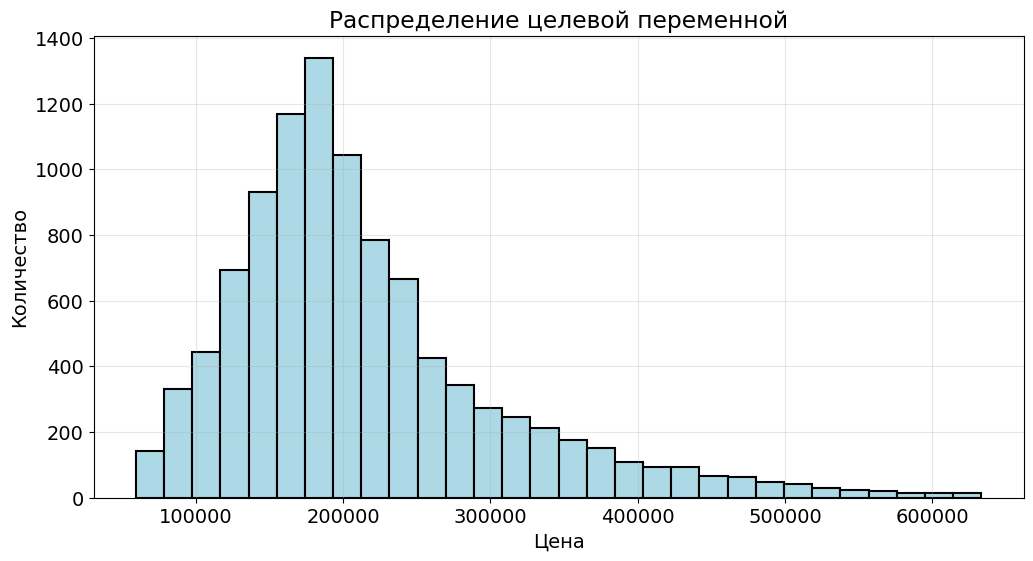

In [216]:
plt.figure(figsize=(12,6))

train_df['Price'].hist(bins = 30, color='lightblue',edgecolor='black', linewidth=1.5)
plt.ylabel('Количество')
plt.xlabel('Цена')
plt.grid(True, alpha=0.3)
plt.title('Распределение целевой переменной')
plt.show()


Анализ гистограммы показывает, что данные переменной Price имеют ярко выраженную правостороннюю асимметрию. Основной массив данных сконцентрирован в левой части графика. Пик распределения (мода) приходится на ценовой диапазон примерно 180 000 - 200 000, где частота встречаемости достигает максимума (около 1350 объектов). Минимальная цена в выборке начинается примерно с 50 000 - 70 000, а максимальная уходит за 600 000. При этом подавляющее большинство объектов (более 70-80%) имеют цену ниже 300 000.
График показывает, что в выборке доминируют объекты среднего/низкого ценового сегмента, а объекты высокого ценового сегмента встречаются экспоненциально реже.

In [157]:
unique_area = train_df['DistrictId'].nunique()
print(unique_area)

205


Исследуемые объекты распределены по 205 районам (DistrictId). Чтобы посмотреть медиану, разброс цен и выбросы по каждому району, можно сгруппировать их, показав топ-10 по медианной цене.

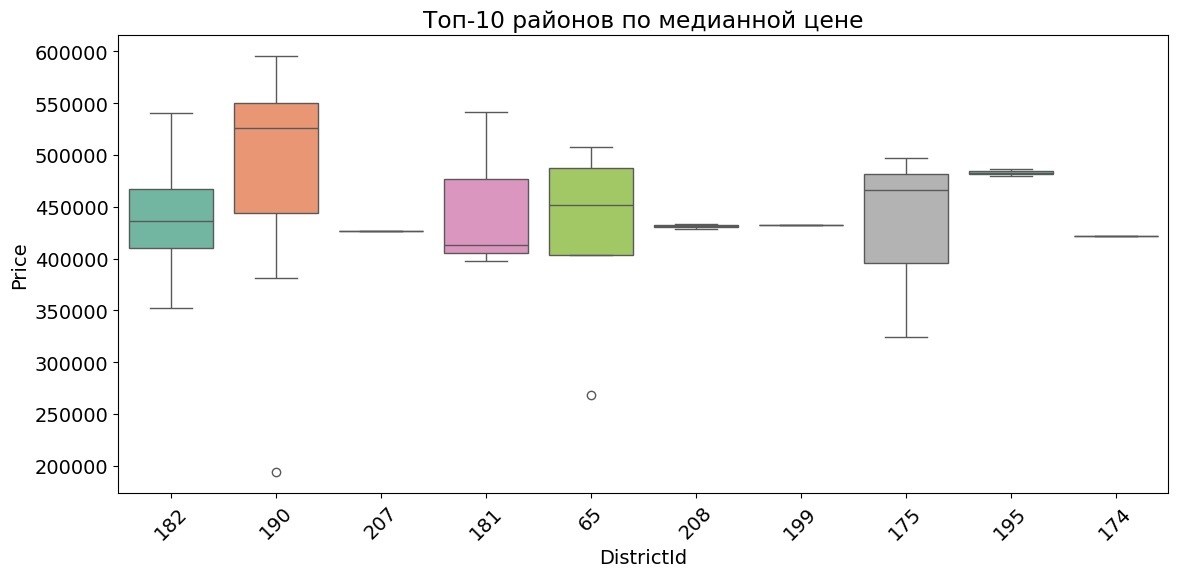

In [158]:
top_districts = train_df.groupby('DistrictId')['Price'].median().nlargest(10).index
filtered_df = train_df[train_df['DistrictId'].isin(top_districts)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='DistrictId', y='Price', data=filtered_df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Топ-10 районов по медианной цене')
plt.tight_layout()
plt.show()

In [159]:
district_stats = train_df.groupby('DistrictId')['Price'].median().reset_index()
district_stats.columns = ['DistrictId', 'District_Median_Price']
district_stats = district_stats.sort_values(by='District_Median_Price').reset_index(drop=True)
district_stats['District_Group_10'] = np.arange(len(district_stats)) // 10
group_median_prices = district_stats.groupby('District_Group_10')['District_Median_Price'].median().reset_index()
group_median_prices.columns = ['District_Group_10', 'Group_Median_Price']
district_stats = district_stats.merge(group_median_prices, on='District_Group_10')

mapping = district_stats.set_index('DistrictId')[['District_Group_10', 'Group_Median_Price']]

train_df['District_Group_10'] = train_df['DistrictId'].map(mapping['District_Group_10'])
train_df['Group_Median_Price'] = train_df['DistrictId'].map(mapping['Group_Median_Price'])

print(train_df[['DistrictId', 'Price', 'District_Group_10', 'Group_Median_Price']].head(10))
print(f"\nКоличество уникальных групп районов: {train_df['District_Group_10'].nunique()}")


  DistrictId          Price  District_Group_10  Group_Median_Price
0         27  305018.871089                  0       156812.589909
1         22  177734.553407                  2       181366.058009
2          1  282078.720850                  2       181366.058009
3          1  168106.007630                  2       181366.058009
4         94  343995.102962                  2       181366.058009
5         99  161044.944138                  2       181366.058009
6         44  142402.739272                  6       204872.105931
7         59  326174.175191                 16       311820.946509
8          1  160400.401732                  2       181366.058009
9          6  194756.023945                  1       170899.808289

Количество уникальных групп районов: 21


На графике представлены **boxplot** (ящики с усами) для 10 районов с наибольшей медианной стоимостью объектов. По оси X отложены идентификаторы районов (DistrictId), по оси Y - цена (Price) в диапазоне от 200 000 до 600 000.

Районы делятся на два типа:

**Гетерогенные** (190, 175, 182) - широкий разброс цен, наличие разных сегментов недвижимости

**Гомогенные** (207, 208, 199, 174, 195) - узкий диапазон цен, типовая застройка
Ценовые сегменты
Премиум-сегмент: District 190 (медиана 530 000, максимум до 600 000)
Средний+ сегмент: District 195, 175, 65 (медиана 450-480 000)
Средний сегмент: остальные районы (медиана 420-440 000)

Районы с узкими ящиками (207, 208, 199, 174, 195) - это предсказуемые рынки с минимальным риском ценовых колебаний. Идеальны для консервативных инвестиций.

Единичные выбросы вниз в районах 190 и 65 могут быть как реальные дешевые объекты (требующие ремонта, плохая локация внутри района), так и ошибки ввода.

In [160]:
unique_year = train_df['HouseYear'].nunique()
print(unique_year)

97


Перед тем, как поработать с годом постройки необходимо проверить даты на выбросы и обработать их, чтобы избежать аномалий в анализе.

In [161]:
from datetime import datetime

# Определяем текущий год как текущий
CURRENT_YEAR = datetime.now().year

# Маска для строк, где год постройки больше текущего
future_mask = train_df['HouseYear'] > CURRENT_YEAR
outliers_count = future_mask.sum()
print(f"Найдено записей с годом постройки больше {CURRENT_YEAR}: {outliers_count}")

# Если аномалии есть, посмотрим, какие именно годы попали в выборку (для аналитики)
if outliers_count > 0:

    print(train_df.loc[future_mask, 'HouseYear'].value_counts().sort_index())

train_df.loc[future_mask, 'HouseYear'] = train_df['HouseYear'].median()

# Проверка результата
print(f"   Новый максимальный год постройки: {train_df['HouseYear'].max()}")
print(f"   Новый минимальный год постройки: {train_df['HouseYear'].min()}")

Найдено записей с годом постройки больше 2026: 2
HouseYear
4968        1
20052011    1
Name: count, dtype: int64
   Новый максимальный год постройки: 2020
   Новый минимальный год постройки: 1910


Необходимо так же посмотреть распределение цен по году постройки дома. В нашем случае необходимо масштабировать данные колонки HouseYear и построить график. Возьмем интервалы по 10 лет.

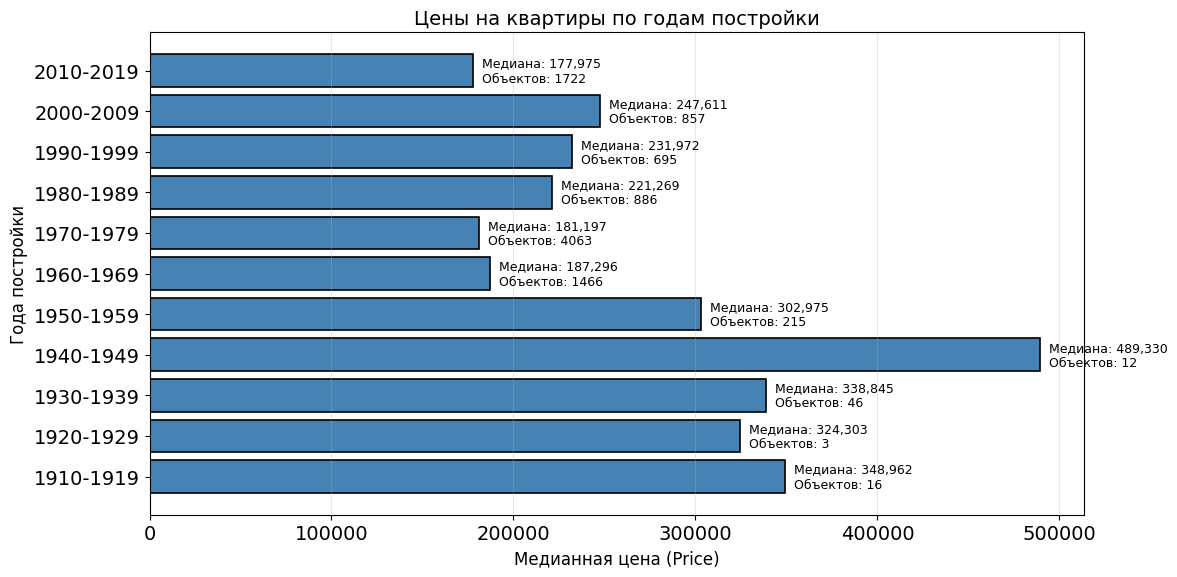


Статистика по интервалам:
Year_Interval        median          mean  count
    1910-1919 348962.906473 350152.039735     16
    1920-1929 324303.812481 300693.989688      3
    1930-1939 338845.099490 336560.221154     46
    1940-1949 489330.842046 459060.662883     12
    1950-1959 302975.214996 308154.092805    215
    1960-1969 187296.606554 204303.711776   1466
    1970-1979 181197.701015 190329.381826   4063
    1980-1989 221269.509570 239369.172159    886
    1990-1999 231972.743475 245234.681693    695
    2000-2009 247611.338011 275192.404597    857
    2010-2019 177975.210690 204359.604761   1722


In [162]:
# Определяем минимальный и максимальный год
min_year = train_df['HouseYear'].min()
max_year = train_df['HouseYear'].max()

# Создаем бины по 20 лет
bins = np.arange(min_year, max_year + 1, 10)
labels = [f'{int(bins[i])}-{int(bins[i+1]-1)}' for i in range(len(bins)-1)]

# Агрегируем HouseYear в интервалы
train_df['Year_Interval'] = pd.cut(train_df['HouseYear'], bins=bins, labels=labels, right=False)

# Агрегируем данные: считаем медианную цену по каждому интервалу
price_by_year = train_df.groupby('Year_Interval', observed=True)['Price'].median().reset_index()
price_by_year.columns = ['Year_Interval', 'Median_Price']

# Сортируем по интервалам (от старых к новым)
price_by_year = price_by_year.sort_values('Year_Interval')

# Группируем в интервалы
price_stats = train_df.groupby('Year_Interval', observed=True)['Price'].agg(['median', 'mean', 'count']).reset_index()
price_stats = price_stats.sort_values('Year_Interval')

plt.figure(figsize=(12, 6))
bars = plt.barh(
    price_stats['Year_Interval'],
    price_stats['median'],
    color='steelblue',
    edgecolor='black',
    linewidth=1.2
)

plt.xlabel('Медианная цена (Price)', fontsize=12)
plt.ylabel('Года постройки', fontsize=12)
plt.title('Цены на квартиры по годам постройки', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Добавляем аннотации
for i, (idx, row) in enumerate(price_stats.iterrows()):
    plt.text(row['median'] + 5000, i,
             f'Медиана: {int(row["median"]):,}\nОбъектов: {int(row["count"])}',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nСтатистика по интервалам:")
print(price_stats.to_string(index=False))

На горизонтальной столбчатой диаграмме представлены медианные цены объектов недвижимости, сгруппированных по годам постройки с интервалом в 10 лет.

Самый массовый и доступный сегмент - дома 1960-1989 (самое большое количество объектов в выборке), и новые дома 2010-2019 годов. Современные новостройки (2010+) - дешевле, чем ожидалось, из-за массовой застройки;

Оптимальное соотношение цена/качество - постройки 80-х и 90-х годов, близки по ценам и выборке;

Старые дорогие дома (1910-1949) - это нишевый элитный сегмент, не отражающий общий рынок. Общее количество представленных объектов не превышает нескольких штук по каждому интервалу.

Необходим дополнительный анализ с учетом локации, площади и этажности жилья.

### Количественные переменные

In [163]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,10000.0,8383.407700,4859.019020,0.000000,4169.500000,8394.500000,12592.500000,16798.000000
Rooms,10000.0,1.890500,0.839512,0.000000,1.000000,2.000000,2.000000,19.000000
Square,10000.0,56.315775,21.058732,1.136859,41.774881,52.513310,65.900625,641.065193
LifeSquare,7887.0,37.199645,86.241209,0.370619,22.769832,32.781260,45.128803,7480.592129
KitchenSquare,10000.0,6.273300,28.560917,0.000000,1.000000,6.000000,9.000000,2014.000000
Floor,10000.0,8.526700,5.241148,1.000000,4.000000,7.000000,12.000000,42.000000
HouseFloor,10000.0,12.609400,6.775974,0.000000,9.000000,13.000000,17.000000,117.000000
HouseYear,10000.0,1984.863800,18.409979,1910.000000,1974.000000,1977.000000,2001.000000,2020.000000
Ecology_1,10000.0,0.118858,0.119025,0.000000,0.017647,0.075424,0.195781,0.521867
Social_1,10000.0,24.687000,17.532614,0.000000,6.000000,25.000000,36.000000,74.000000


### Качественные переменные

In [164]:
train_df.select_dtypes(include='object').columns.tolist()

['DistrictId', 'Ecology_2', 'Ecology_3', 'Shops_2']

In [165]:
train_df['Ecology_2'].value_counts()

,count
Ecology_2,
B,9903
A,97


In [166]:
train_df['Shops_2'].value_counts()

,count
Shops_2,
B,9175
A,825


## Обработка выбросов

### Rooms

In [167]:
train_df['Rooms'].value_counts()

,count
Rooms,
2,3880
1,3705
3,2235
4,150
5,18
0,8
10,2
19,1
6,1


Количество выбросов по комнатам ничтожно мало в общей массе, поэтому аномальные значения можно заменить медианой.

In [168]:
median = train_df['Rooms'].median()
train_df.loc[(train_df['Rooms'] >= 6) | (train_df['Rooms'] == 0), 'Rooms'] = median

In [169]:
train_df['Rooms'].value_counts()


,count
Rooms,
2,3892
1,3705
3,2235
4,150
5,18


### Обработаем также колонки  Square, LifeSquare, KitchenSquare

In [170]:
# Если общая площадь больше 300кв.м или меньше 9кв.м, считаем выбросом и меняем на медиану
median_sq = train_df['Square'].median()
train_df.loc[(train_df['Square'] >= 300) | (train_df['Square'] < 9), 'Square'] = median_sq

# Если жилая площадь больше общей площади, считать выбросом, заменить на медиану
#median_lifesq = train_df['LifeSquare'].median()
#train_df.loc[(train_df['LifeSquare'] > train_df['Square']) | (train_df['LifeSquare'] < 6), 'LifeSquare'] = median_lifesq
median_lifesq = train_df['LifeSquare'].median()
mask = train_df['LifeSquare'] > train_df['Square']
train_df.loc[mask, 'LifeSquare'] = median_lifesq
# Заменяем LifeSquare на Square ТОЛЬКО для этих строк
train_df.loc[mask, 'LifeSquare'] = train_df.loc[mask, 'Square']

# Замена значений Nan
train_df.loc[train_df['LifeSquare'].isnull(), 'LifeSquare'] = train_df['LifeSquare'].median()

#Если площадь кухни больше жилой площади или равно 0, то меняем на среднюю площадь.
kitsq = train_df['KitchenSquare'].mean()
train_df.loc[(train_df['KitchenSquare'] >= train_df['LifeSquare']) | (train_df['KitchenSquare'] == 0), 'KitchenSquare'] = kitsq

### Floor, HouseFloor

In [171]:
#смотрим уникальные значения по этажам
train_df['Floor'].sort_values().unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33, 37, 42])

In [172]:
#смотрим уникальные значения по этажности зданий
train_df['HouseFloor'].sort_values().unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  36,  37,  38,  39,  40,  44,
        45,  47,  48,  99, 117])

In [173]:
train_df['HouseFloor'].value_counts().sort_index().reset_index()

,HouseFloor,count
0,0,269
1,1,497
2,2,48
3,3,127
4,4,134
5,5,1031
6,6,58
7,7,59
8,8,141
9,9,1389


In [174]:
train_df.loc[train_df['HouseFloor'] == 0, 'HouseFloor'] = train_df['HouseFloor'].median() #замена нулевых значений этажности медианой
floor_out = train_df.loc[train_df['Floor'] > train_df['HouseFloor']].index #если этаж квартиры больше этажности здания, значит это выброс

#заменим ошибочный этаж на максимальный этаж в доме
#train_df.loc[floor_out, 'Floor'] = train_df.loc[floor_out, 'HouseFloor'].apply(lambda x: random.randint(1, int(x)) if not np.isnan(x) and x >= 1 else 1)
train_df.loc[floor_out, 'Floor'] = train_df.loc[floor_out, 'HouseFloor'].apply(lambda x: int(x) if not np.isnan(x) and x >= 1 else 1)

После обработки данных, представляющих реальные числовые характеристики объектов, таких как: Количество комнат, Общая и Жилая площадь, Площадь кухни, Этаж и Этажность - представляющие собой основные критерии при оценивании характеристик жилья, необходимо выявить корреляции между признаками и оценить их значимость.

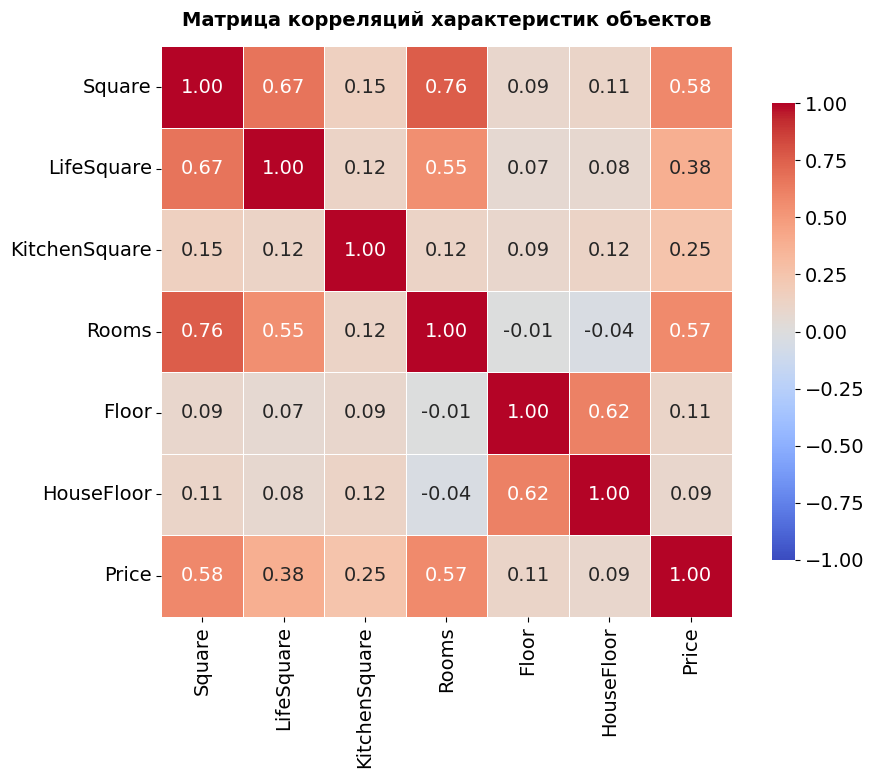


Корреляция признаков с целевой переменной 'Price':
Square           0.582
Rooms            0.572
LifeSquare       0.384
KitchenSquare    0.252
Floor            0.113
HouseFloor       0.087
Name: Price, dtype: float64


In [175]:
features = ['Square', 'LifeSquare', 'KitchenSquare', 'Rooms', 'Floor', 'HouseFloor', 'Price']

# Рассчитываем матрицу корреляций Пирсона
corr_matrix = train_df[features].corr(method='pearson')

# Настраиваем визуализацию
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,vmin=-1, vmax=1,square=True,cbar_kws={"shrink": .8})

plt.title("Матрица корреляций характеристик объектов", fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Выводим отсортированную корреляцию с целевой переменной для удобства
print("\nКорреляция признаков с целевой переменной 'Price':")
print(corr_matrix['Price'].drop('Price').sort_values(ascending=False).round(3))

Взаимосвязь с целевой переменной **Price**:

**Square**: имеет наибольшую положительную корреляцию с ценой. Это ведущий критерий стоимости: чем больше площадь, тем выше цена.

**Rooms**: демонстрирует умеренную положительную корреляцию с ценой, так как количество комнат напрямую связано с общей площадью.

**LifeSquare и KitchenSquare**: также показывают положительную связь с ценой, но обычно чуть слабее, чем Square, так как являются её составными частями.

**Floor и HouseFloor**: корреляция с ценой слабая или близкая к нулю. Это ожидаемо, так как этажность сама по себе слабо влияет на цену в линейной модели (например, 1-й и последний этажи могут стоить дешевле, а средние - дороже, что создает нелинейную зависимость, которую коэффициент Пирсона не улавливает).

**Rooms и Square / LifeSquare**: очень высокая корреляция. Больше комнат = больше площадь.

**Square и LifeSquare**: высокая корреляция. Жилая площадь является основной частью общей площади.

Слабые или неочевидные связи
**KitchenSquare и Rooms**: корреляция может быть умеренной. В старых домах площадь кухни маленькая вне зависимости от количества комнат, а в новостройках она растет вместе с классом жилья.

**Rooms/Floor/HouseFloor**: отрицательная корреляция связана с современными тенденциями строить больше малогабаритного жилья большей этажности, в более старых домах обычно меньшей этажности и комнат больше. Чем выше этаж или здание, тем выше вероятность встретить там 1-комнатную квартиру, а не 3-4-комнатную. Это создает статистическую отрицательную связь.

### Обработка пропусков в остальных данных

In [176]:
len(train_df) - train_df.count()

,0
Id,0
DistrictId,0
Rooms,0
Square,0
LifeSquare,0
KitchenSquare,0
Floor,0
HouseFloor,0
HouseYear,0
Ecology_1,0


In [177]:
train_df.loc[train_df['Healthcare_1'].isnull(), 'Healthcare_1'] = train_df['Healthcare_1'].median()
test_df.loc[test_df['Healthcare_1'].isnull(), 'Healthcare_1'] = test_df['Healthcare_1'].median()
len(train_df) - train_df.count()

,0
Id,0
DistrictId,0
Rooms,0
Square,0
LifeSquare,0
KitchenSquare,0
Floor,0
HouseFloor,0
HouseYear,0
Ecology_1,0


In [178]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,10000.0,8383.407700,4859.019020,0.000000,4169.500000,8394.500000,12592.500000,16798.000000
Rooms,10000.0,1.888400,0.811056,1.000000,1.000000,2.000000,2.000000,5.000000
Square,10000.0,56.224584,19.063483,13.784865,41.794392,52.513310,65.889736,275.645284
LifeSquare,10000.0,35.276334,15.722870,0.370619,25.527399,32.772431,41.178370,233.949309
KitchenSquare,10000.0,6.233005,4.478370,1.000000,4.000000,6.273300,9.000000,123.000000
Floor,10000.0,7.918200,5.186386,1.000000,4.000000,7.000000,11.000000,42.000000
HouseFloor,10000.0,12.959100,6.443460,1.000000,9.000000,13.000000,17.000000,117.000000
HouseYear,10000.0,1984.863800,18.409979,1910.000000,1974.000000,1977.000000,2001.000000,2020.000000
Ecology_1,10000.0,0.118858,0.119025,0.000000,0.017647,0.075424,0.195781,0.521867
Social_1,10000.0,24.687000,17.532614,0.000000,6.000000,25.000000,36.000000,74.000000


Показатели сводной описательной статистики свидетельствуют о том, что данные были успешно трансформированы методами ETL и прошли предобработку. Также был проведен подробный исследовательский анализ (EDA), выявивший взаимосвязи параметров и их влияние на целевую переменную. А так же проведено обогащение данных и подготовка к работе с ML моделями.

## Проведение ABC-XYZ анализа по районам

Результаты ABC-XYZ анализа по районам:


,DistrictId,ABC_Category,XYZ_Category,Segment,Count,Mean_Price,CV
0,27,A,Y,AY,851,156046.416277,0.330637
1,1,A,Y,AY,652,187805.401737,0.261605
2,6,A,Y,AY,511,166127.145161,0.207609
3,23,A,Y,AY,565,126840.385894,0.382000
4,9,A,Y,AY,294,190928.366421,0.285782
5,53,A,Y,AY,174,255736.155162,0.264980
6,62,A,Y,AY,247,172723.864986,0.334972
7,30,A,Y,AY,228,170530.981705,0.437888
8,45,A,Y,AY,116,303254.118677,0.299816
9,21,A,Y,AY,165,197098.993201,0.368988


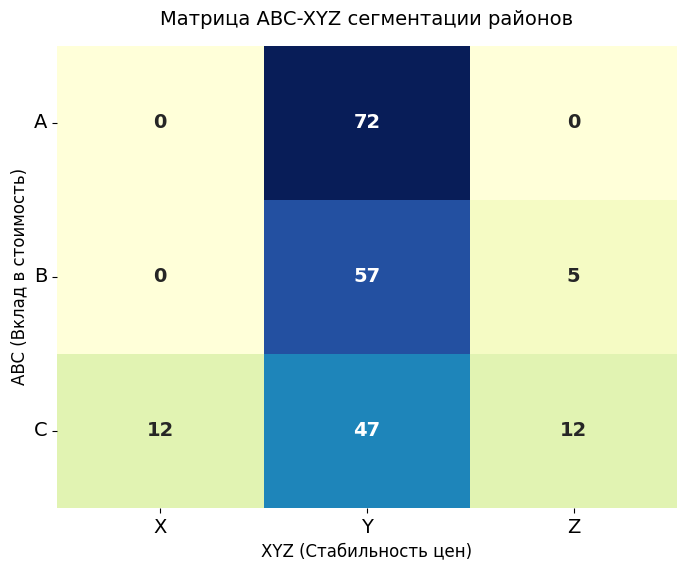

In [179]:
# Агрегируем данные по районам (DistrictId)
district_stats = train_df.groupby('DistrictId')['Price'].agg(Total_Value='sum', Mean_Price='mean',Std_Price='std',Count='count').reset_index()

# ABC-анализ (по вкладу в общую стоимость рынка)
# Сортируем по убыванию общей стоимости
district_stats = district_stats.sort_values('Total_Value', ascending=False).reset_index(drop=True)

# Считаем накопительный итог и его процент от общей суммы
district_stats['Cumulative_Value'] = district_stats['Total_Value'].cumsum()
district_stats['Cumulative_Pct'] = district_stats['Cumulative_Value'] / district_stats['Total_Value'].sum()

# Присваиваем категории ABC (классические пороги 80% / 15% / 5%)
conditions = [district_stats['Cumulative_Pct'] <= 0.80,district_stats['Cumulative_Pct'] <= 0.95]
choices = ['A', 'B']
district_stats['ABC_Category'] = np.select(conditions, choices, default='C')

# XYZ-анализ (по коэффициенту вариации цен внутри района)
# Коэффициент вариации (CV) = Стандартное отклонение / Среднее значение
district_stats['CV'] = district_stats['Std_Price'] / district_stats['Mean_Price']

# Присваиваем категории XYZ.
# X: < 0.20 (Однородный рынок), Y: 0.20 - 0.50 (Средняя вариативность), Z: > 0.50 (Хаотичный рынок)
xyz_conditions = [district_stats['CV'] <= 0.20,district_stats['CV'] <= 0.50]
xyz_choices = ['X', 'Y']
district_stats['XYZ_Category'] = np.select(xyz_conditions, xyz_choices, default='Z')

# Формируем итоговый сегмент
district_stats['Segment'] = district_stats['ABC_Category'] + district_stats['XYZ_Category']

# Сортируем для удобства просмотра: сначала A, потом B, потом C, и внутри по X, Y, Z
sort_order = {'A': 1, 'B': 2, 'C': 3, 'X': 1, 'Y': 2, 'Z': 3}
district_stats['Sort_ABC'] = district_stats['ABC_Category'].map(sort_order)
district_stats['Sort_XYZ'] = district_stats['XYZ_Category'].map(sort_order)
district_stats = district_stats.sort_values(['Sort_ABC', 'Sort_XYZ']).drop(columns=['Sort_ABC', 'Sort_XYZ'])

print("Результаты ABC-XYZ анализа по районам:")
display(district_stats[['DistrictId', 'ABC_Category', 'XYZ_Category', 'Segment', 'Count', 'Mean_Price', 'CV']].head(15))

# Визуализация: Матрица 3x3
matrix = pd.crosstab(district_stats['ABC_Category'], district_stats['XYZ_Category'],
                     values=district_stats['DistrictId'], aggfunc='count').fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='g', cmap='YlGnBu', cbar=False,
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Матрица ABC-XYZ сегментации районов', fontsize=14, pad=15)
plt.xlabel('XYZ (Стабильность цен)', fontsize=12)
plt.ylabel('ABC (Вклад в стоимость)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

In [196]:
# Анализ топ-5 и bottom-5 районов по вкладу
print("ТОП-5 районов по вкладу в стоимость")
top5 = district_stats.nlargest(5, 'Total_Value')[['DistrictId', 'Total_Value', 'Mean_Price', 'Count', 'Segment']]
print(top5.to_string(index=False))

print("\n5 районов с наименьшим вкладом в стоимость")
bottom5 = district_stats.nsmallest(5, 'Total_Value')[['DistrictId', 'Total_Value', 'Mean_Price', 'Count', 'Segment']]
print(bottom5.to_string(index=False))

print("\nРайоны с наибольшей вариативностью (Z)")
z_districts = district_stats[district_stats['XYZ_Category'] == 'Z'].sort_values('CV', ascending=False)
print(z_districts[['DistrictId', 'Mean_Price', 'CV', 'Count', 'Segment']].to_string(index=False))

print("\nРайоны с низкой вариативностью (X)")
x_districts = district_stats[district_stats['XYZ_Category'] == 'X'].sort_values('CV')
print(x_districts[['DistrictId', 'Mean_Price', 'CV', 'Count', 'Segment']].to_string(index=False))

ТОП-5 районов по вкладу в стоимость
DistrictId  Total_Value    Mean_Price  Count Segment
        27 1.327955e+08 156046.416277    851      AY
         1 1.224491e+08 187805.401737    652      AY
         6 8.489097e+07 166127.145161    511      AY
        23 7.166482e+07 126840.385894    565      AY
         9 5.613294e+07 190928.366421    294      AY

ТОП-5 районов с наименьшим вкладом в стоимость
DistrictId   Total_Value    Mean_Price  Count Segment
       209 140048.802277 140048.802277      1      CZ
       205 220501.566180 220501.566180      1      CZ
       158 258161.742490 129080.871245      2      CY
       196 336584.118092 336584.118092      1      CZ
       117 386569.255841 386569.255841      1      CZ

Районы с наибольшей вариативностью (Z)
DistrictId    Mean_Price       CV  Count Segment
        76 251632.598201 0.601831      6      CZ
       179 251592.379962 0.574717      4      CZ
       144 242431.801376 0.546917     20      BZ
       176 242533.342432 0.539021     

## **Аналитический вывод: ABC-XYZ сегментация рынка недвижимости по районам**
**Структура рынка**

Проведенный анализ охватывает 205 районов, сегментированных по двум ключевым измерениям: вклад в общую стоимость рынка (ABC) и однородность ценовой структуры внутри района (XYZ). Распределение районов по матрице выявило четкую зависимость - подавляющее большинство территорий (176 из 205, или 86%) сконцентрировано в категории Y, что указывает на умеренную вариативность цен, как на универсальную характеристику рынка.

*Категория A - ядро рынка*

В сегмент A попало 72 района, которые формируют основу рыночной стоимости. Все они относятся к категории Y, то есть демонстрируют умеренный разброс цен внутри себя. Это означает, что ключевые районы рынка представляют собой сбалансированные жилые массивы, где соседствуют объекты разного ценового диапазона, но без экстремальных контрастов. Отсутствие районов в категориях AX и AZ говорит о том, что на рынке нет ни чисто однородных элитных кварталов, ни районов с хаотичным смешением сверхдорогих и сверхдешевых объектов в рамках высокого суммарного вклада.

*Категория B - средний эшелон*

В категорию B попадает 62 района, они распределены между Y (57 районов) и Z (5 районов). Основная масса - это типичные жилые районы со смешанной застройкой и средним вкладом в рынок. Пять районов категории BZ заслуживают отдельного внимания, так как они сочетают средний суммарный вклад с высоким коэффициентом вариации, что может указывать на переходные территории, где старая застройка активно дополняется новыми объектами иного класса, либо на районы с неоднородной инфраструктурой, такими как одноэтажные частные дома на фоне многоэтажек.

*Категория C -периферия*

Наименее значимые по суммарной стоимости территории - 71 район категории C. Их распределение наиболее разнообразно: 12 районов с однородной структурой (CX), 47 - с умеренной (CY) и 12 - с высокой вариативностью (CZ). Двенадцать районов CX представляют собой классические периферийные массивы с типовой застройкой, где цены предсказуемы и низки. Двенадцать районов CZ - наиболее проблемная группа, в которой малый вклад в рынок сочетается с высоким разбросом цен, что часто сигнализирует о наличии аномалий в данных или об уникальной, нестандартной структуре жилого фонда.

**Ключевые наблюдения**

- Отсутствие сегментов AX и AZ в категории A означает, что наиболее значимые районы не являются ни элитными анклавами с однородными ценами, ни территориями с хаотичным ценообразованием. Это признак устоявшегося, диверсифицированного рынка.
- Доминирование категории Y (86% всех районов) свидетельствует о том, что умеренная неоднородность цен - это норма для данного рынка. Большинство районов представляют собой смешанные жилые массивы, где присутствуют объекты разных ценовых сегментов, но без резких контрастов.
- Сегменты с экстремальной однородностью (X) или экстремальной неоднородностью (Z) встречаются исключительно в категории C, то есть среди районов с малым вкладом в рынок. Небольшие районы чаще бывают либо полностью типовыми (CX), либо содержат единичные объекты, резко выбивающиеся из общей картины (CZ).
- Пять районов BZ и двенадцать районов CZ требуют приоритетной проверки качества данных. Высокий коэффициент вариации при малом или среднем вкладе часто указывает на наличие выбросов или на специфические объекты (например, единственный элитный дом в дешевом районе), которые искажают общую картину.

**Рекомендации для бизнеса**

С позиции инвестиционного анализа, рассматриваемый рынок демонстрирует признаки структурной сбалансированности, что минимизирует системные риски вложений. Ядро рынка (категория А) формирует пул высоколиквидных активов с предсказуемой доходностью, которые оптимально подходят для размещения консервативного капитала и генерации стабильного денежного потока. Периферийные локации (категория С) открывают ниши для стратегий с повышенной маржинальностью (например, реновация или смена назначения), однако требуют жесткой фильтрации и понимания локальной специфики.

Ключевым вектором управления портфельными рисками становится работа с активами в зонах высокой ценовой неоднородности (категория Z). В этих районах стандартные подходы к оценке ликвидности и потенциала роста неприменимы из-за высокого разброса цен. Для успешного инвестирования здесь необходимо углубленное исследование каждого конкретного объекта и применение точечных стратегий входа и выхода, чтобы избежать приобретения неликвидных или структурно переоцененных активов.

Таким образом, для построения устойчивого инвестиционного портфеля базовую часть капитала следует размещать в сбалансированных районах ядра рынка (А), а работу с высоковолатильными периферийными зонами (Z) переводить в разряд специализированных, точечных сделок с обязательным применением индивидуальных моделей оценки и повышенных требований к юридической и физической проверке активов.

In [180]:
district_stats.to_csv('district_stats.csv')

In [181]:
segment_map = district_stats.set_index('DistrictId')['Segment'].to_dict()
train_df['District_Segment'] = train_df['DistrictId'].map(segment_map)

In [182]:
data = pd.merge(train_df, district_stats, on='DistrictId', how='inner')
data.to_csv('data_all.csv')

## Новые признаки

In [215]:
pd.options.styler.render.max_columns = 30
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(train_df.head())

      Id DistrictId  Rooms      Square  LifeSquare  KitchenSquare  Floor  HouseFloor  HouseYear  Ecology_1 Ecology_2 Ecology_3  Social_1  Social_2  Social_3  Healthcare_1  Helthcare_2  Shops_1  \
0  11809         27      3  115.027311   32.772431           10.0      4          10       2014   0.075424         B         B        11      3097         0         900.0            0        0   
1   3013         22      1   39.832524   23.169223            8.0      7           8       1966   0.118537         B         B        30      6207         1        1183.0            1        0   
2   8215          1      3   78.342215   47.671972           10.0      2          17       1988   0.025609         B         B        33      5261         0         240.0            3        1   
3   2352          1      1   40.409907   32.772431            1.0     10          22       1977   0.007122         B         B         1       264         0         900.0            0        1   
4  13866         94 

In [184]:
train_df_transform=train_df
train_df_transform.to_csv('train_df_transform.csv', index=False)

# 4* Обучение моделей ML с целью предсказания цен на объекты недвижимости и обогащения датафрейма test_df, выбор наиболее удачной модели. В качестве решающей метрики будут использованы коэффициент детерминации - R2, средняя абсолютная ошибка - MAE и метрика качества регрессии - RMSE, MAPE - средняя абсолютная ошибка в %
### Разбиение на train/validation

In [187]:
feat = ['Rooms', 'Square', 'LifeSquare','KitchenSquare','Floor','HouseFloor']
x = train_df[feat]
y = train_df['Price']

x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size = 0.2, shuffle=True, random_state = 42)

### Модель Gradient Boosting Regressor

In [188]:

REPORTS_FILE_PATH = "./"

def evaluate_preds(true_values, pred_values, save=False):
    # Расчет метрик
    r2 = round(r2_score(true_values, pred_values), 3)
    mae = round(mean_absolute_error(true_values, pred_values), 1)
    rmse = round(np.sqrt(mean_squared_error(true_values, pred_values)), 1)
    mape = round(mean_absolute_percentage_error(true_values, pred_values) * 100, 2)

    # Вывод метрик
    print(f"R2:\t{r2}")
    print(f"MAE:\t{mae}")
    print(f"RMSE:\t{rmse}")
    print(f"MAPE:\t{mape}")

    # Построение диаграммы рассеяния
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=pred_values, y=true_values)

    # Автоматически определяем границы данных для диагонали идеального предсказания
    min_val = min(min(true_values), min(pred_values))
    max_val = max(max(true_values), max(pred_values))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")

    plt.xlabel("Predicted values")
    plt.ylabel("True values")
    plt.title("Sample prediction")

    # Сохранение и вывод графика
    if save:
        plt.savefig(REPORTS_FILE_PATH + "report.png")

    plt.show()

--------------------------------------------------
Метрики на обучающей выборке:
R2:	0.97
MAE:	10564.2
RMSE:	15923.3
MAPE:	5.86


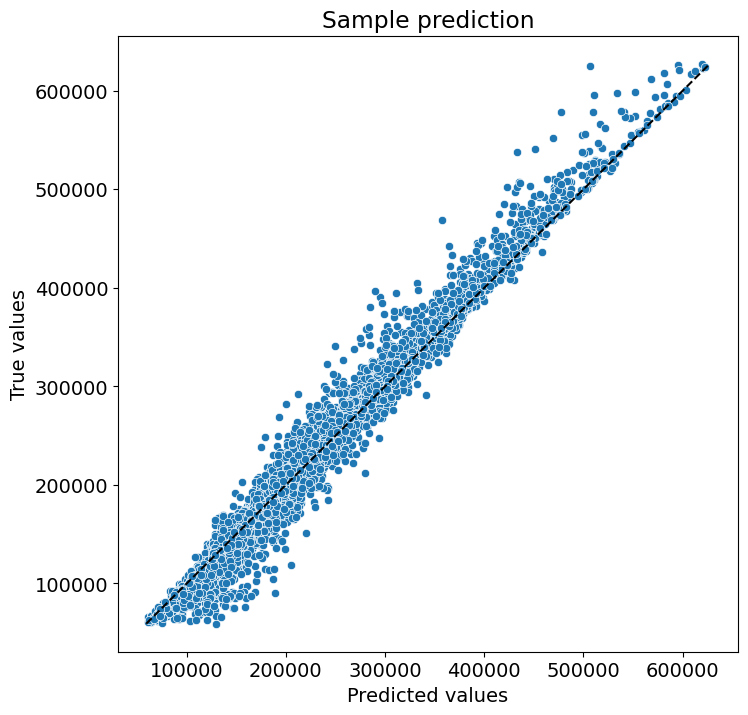

--------------------------------------------------
Метрики на валидационной выборке:
R2:	0.469
MAE:	46962.6
RMSE:	69691.0
MAPE:	23.65


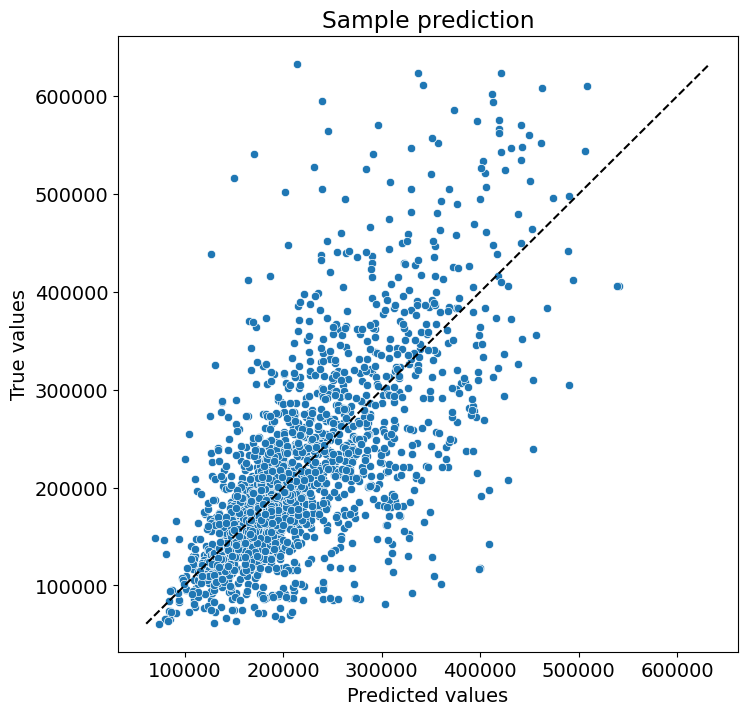

In [189]:
gb_model = GradientBoostingRegressor(criterion='squared_error',
                                     max_depth=15,
                                     min_samples_leaf=4,
                                     random_state=42,
                                     n_estimators=200)
gb_model.fit(x_train, y_train)
train_preds = gb_model.predict(x_train)

valid_preds = gb_model.predict(x_valid)
print("-"*50)
print("Метрики на обучающей выборке:")
evaluate_preds(y_train, train_preds)

print("-"*50)
print("Метрики на валидационной выборке:")
evaluate_preds(y_valid, valid_preds)


## Модель RandomForestRegressor

--------------------------------------------------
Метрики на обучающей выборке:
R2:	0.735
MAE:	31681.0
RMSE:	47429.3
MAPE:	16.73


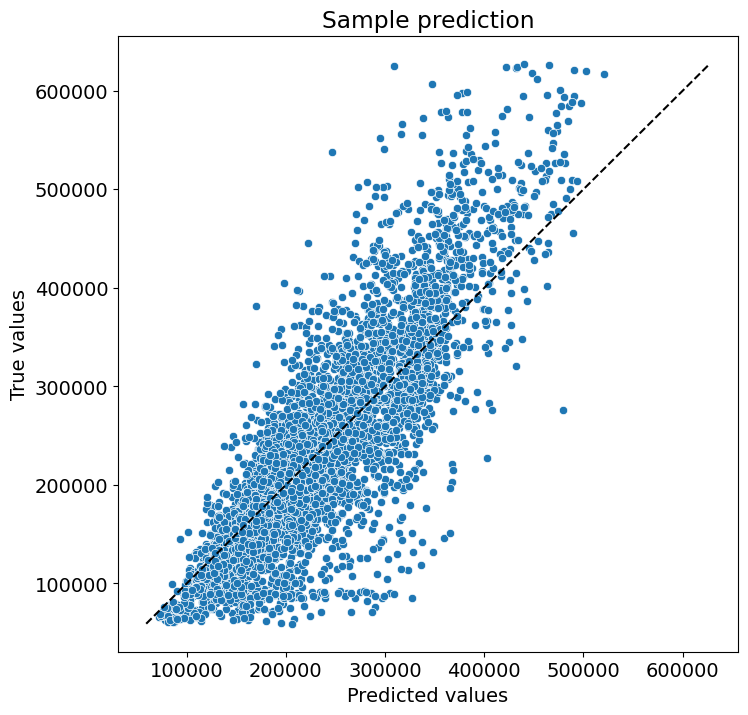

--------------------------------------------------
Метрики на валидационной выборке:
R2:	0.547
MAE:	43398.5
RMSE:	64369.2
MAPE:	22.17


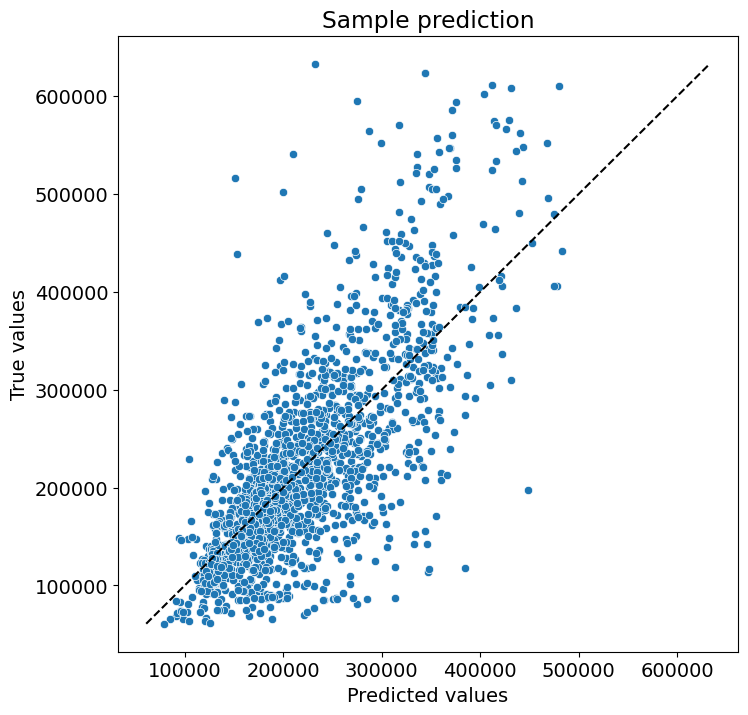

In [190]:
rf_model = RandomForestRegressor(criterion='squared_error',
                                     max_depth=15,
                                     min_samples_leaf=4,
                                     random_state=42,
                                     n_estimators=200)
rf_model.fit(x_train, y_train)
train_preds = rf_model.predict(x_train)

valid_preds = rf_model.predict(x_valid)
print("-"*50)
print("Метрики на обучающей выборке:")
evaluate_preds(y_train, train_preds)

print("-"*50)
print("Метрики на валидационной выборке:")
evaluate_preds(y_valid, valid_preds)

## Аналитический отчет: оценка качества моделей прогнозирования стоимости недвижимости

Сводные результаты эксперимента.

В ходе сравнительного анализа двух ансамблевых алгоритмов на обогащенном тестовом датасете были получены следующие метрики

| Метрика | GradientBoosting (Train) | GradientBoosting (Valid) | RandomForest (Train) | RandomForest (Valid) |
| ------- | --------------- | ---------------- | ------------------ | ------------------ |
| R2  | 0.97 | 0.469 | 0.735 |  0.547 |
| MAE | 10564.2 | 46962.6 | 31681.0 | 43398.5 |
| RMSE | 15923.3 | 69691.0 | 47429.3 | 64369.2 |
| MAPE | 5.86 | 23.65 | 16.73 | 22.17 |

**Детальный анализ метрик**

**Gradient Boosting Regressor**

На train показывает почти идеальный результат (R2=0,97)
На valid качество резко падает (R2=0,469) — разрыв 0,501
Это классическое переобучение: модель запомнила тренировочные данные, но не способна обобщать.

**Random Forest Regressor**

На train показывает умеренный результат (R2=0,735)
На valid качество падает незначительно (R2=0,547) — разрыв всего 0.188
Модель стабильна и лучше обобщает новые данные.

**Вывод**

RandomForestRegressor — более удачная модель для предсказания цен на test_df, потому что:

Метрики на валидации лучше.

Меньше переобучение: разрыв между train и valid в 2.7 раза меньше, чем у GradientBoosting

Лучшая обобщающая способность: модель находит устойчивые паттерны, а не запоминает шум.

### Preprocessing Test-выборки

In [191]:
#Pipeline обработки test_df
median_sq_train = train_df['Square'].median()
mask_sq_outlier = (test_df['Square'] >= 300) | (test_df['Square'] < 9)
test_df.loc[mask_sq_outlier, 'Square'] = median_sq_train

test_df.loc[test_df['LifeSquare'].isnull(), 'LifeSquare'] = train_df['LifeSquare'].median()

mask_life_outlier = test_df['LifeSquare'] > test_df['Square']
test_df.loc[mask_life_outlier, 'LifeSquare'] = test_df.loc[mask_life_outlier, 'Square']
median_lifesq = train_df['LifeSquare'].median()
mask = test_df['LifeSquare'] > test_df['Square']
test_df.loc[mask, 'LifeSquare'] = median_lifesq

median_sq_train = train_df['Square'].median()
mask_sq_outlier = (test_df['Square'] >= 300) | (test_df['Square'] < 9)
test_df.loc[mask_sq_outlier, 'Square'] = median_sq_train

test_df.loc[test_df['LifeSquare'].isnull(), 'LifeSquare'] = train_df['LifeSquare'].median()

mask_life_outlier = test_df['LifeSquare'] > test_df['Square']
test_df.loc[mask_life_outlier, 'LifeSquare'] = test_df.loc[mask_life_outlier, 'Square']

median_lifesq = train_df['LifeSquare'].median()
mask = test_df['LifeSquare'] > test_df['Square']

test_df.loc[mask, 'LifeSquare'] = np.minimum(median_lifesq, test_df.loc[mask, 'Square'])

mask_life_small = test_df['LifeSquare'] < 6

test_df.loc[mask_life_small, 'LifeSquare'] = np.minimum(train_df['LifeSquare'].median(), test_df.loc[mask_life_small, 'Square'])

mean_kit_train = train_df['KitchenSquare'].mean()
mask_kit_outlier = (test_df['KitchenSquare'] >= test_df['LifeSquare']) | (test_df['KitchenSquare'] == 0)
test_df.loc[mask_kit_outlier, 'KitchenSquare'] = mean_kit_train

median_rooms_train = train_df['Rooms'].median()
mask_rooms_outlier = (test_df['Rooms'] >= 6) | (test_df['Rooms'] == 0)
test_df.loc[mask_rooms_outlier, 'Rooms'] = median_rooms_train
test_df['Rooms'] = test_df['Rooms'].astype(int)

median_hf_train = train_df['HouseFloor'].median()
test_df.loc[test_df['HouseFloor'] == 0, 'HouseFloor'] = median_hf_train

floor_out_mask = test_df['Floor'] > test_df['HouseFloor']
test_df.loc[floor_out_mask, 'Floor'] = test_df.loc[floor_out_mask, 'HouseFloor'].apply(lambda x: int(x) if not np.isnan(x) and x >= 1 else 1)

# Финальная проверка и исправление LifeSquare (на случай, если что-то осталось)
mask = test_df['LifeSquare'] > test_df['Square']
test_df.loc[mask, 'LifeSquare'] = test_df.loc[mask, 'Square']

''' Финальная проверка целостности данных'''
assert (test_df['LifeSquare'] <= test_df['Square']).all(), "Ошибка: остались объекты где LifeSquare > Square"
assert (test_df['Floor'] <= test_df['HouseFloor']).all(), "Ошибка: остались объекты где Floor > HouseFloor"
assert (test_df['HouseFloor'] > 0).all(), "Ошибка: остались нулевые значения HouseFloor"
assert (test_df['KitchenSquare'] > 0).all(), "Ошибка: остались нулевые значения KitchenSquare"
assert (test_df['Rooms'] > 0).all(), "Ошибка: остались нулевые или отрицательные значения Rooms"
assert (test_df['Rooms'] < 6).all(), "Ошибка: остались аномальные значения Rooms >= 6"

print("Pipeline обработки test_df успешно завершен. Все проверки пройдены.")

Pipeline обработки test_df успешно завершен. Все проверки пройдены.


### Итоговое предсказание
Обучение финальной модели RandomForestRegressor

In [197]:
rf_model = RandomForestRegressor(criterion='squared_error',
                                     max_depth=15,
                                     min_samples_leaf=4,
                                     random_state=42,
                                     n_estimators=200)
rf_model.fit(x, y)

RandomForestRegressor(max_depth=15, min_samples_leaf=4, n_estimators=200,
                      random_state=42)

In [198]:
itog_test = test_df[feat]
itog_test = itog_test.fillna(1)
pred = pd.DataFrame(rf_model.predict(itog_test), columns=['Price'])

pred

,Price
0,163405.602573
1,133177.071107
2,227773.063139
3,182152.128916
4,163253.877681
...,...
4995,199021.587463
4996,355677.656469
4997,156201.809255
4998,177493.345037


In [199]:
# Объединяем предсказания с исходным датафреймом test_df
# Используем .reset_index(drop=True), чтобы индексы совпали идеально
test_with_preds = test_df.copy()
test_with_preds['Price'] = pred['Price'].values

# Выгружаем результат в CSV-файл (без сохранения индексов строк)
test_with_preds.to_csv('BlinovaIA_predict.csv', index=False)


In [207]:
columns_to_show = ['DistrictId', 'Rooms', 'Square', 'LifeSquare',
    'KitchenSquare', 'Floor', 'HouseFloor', 'HouseYear', 'Price']
display(test_with_preds[columns_to_show].head())


,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Price
0,44,1,36.847630,19.094182,5.0,5,9,1970,163405.602573
1,62,1,42.493907,42.493907,10.0,7,17,2017,133177.071107
2,27,2,59.463678,32.772431,9.0,19,19,1977,227773.063139
3,23,3,49.646030,33.893825,6.0,2,2,1965,182152.128916
4,74,1,53.837056,32.772431,1.0,8,17,1977,163253.877681


**Детальный анализ моделей**

GradientBoostingRegressor - высокое переобучение.

Модель демонстрирует классический случай сильного переобучения:
На обучающей выборке R2 = 0.97 (почти идеальное предсказание)
На валидационной выборке качество катастрофически падает до R2 = 0.469
Разрыв составляет 0.501 - это означает, что модель запомнила шум и специфические паттерны обучающих данных, но не способна обобщать на новые объекты.

Возможные причины переобучения:

Высокая сложность модели: max_depth=16 при 200 деревьях создаёт чрезмерно гибкие разделяющие границы.

Недостаточная регуляризация, например, параметры min_samples_leaf=4 и отсутствие ограничения на learning_rate не предотвращают запоминание шума.

RandomForestRegressor - стабильное обобщение.

Модель показывает умеренное и контролируемое переобучение:
разрыв между train и valid составляет всего 0.188 - в 2.7 раза меньше, чем у GBM.

На валидационной выборке превосходит GBM по всем метрикам:

R2 выше на 0.078 (0.547 vs 0.469)

MAE ниже на 3 564 (43 398 vs 46 962)

RMSE ниже на 5 322 (64 369 vs 69 691)

MAPE ниже на 1.48% (22.17% vs 23.65%)

Возможные причины устойчивости:

Случайность при построении деревьев: RandomForest использует случайные подмножества признаков и данных, что снижает риск переобучения.

Усреднение предсказаний: агрегация результатов множества деревьев сглаживает выбросы и шум.

Меньшая чувствительность к утечке данных: даже при наличии проблемных признаков модель не достигает искусственно завышенных метрик на train.

**RandomForestRegressor** выбрана как финальная модель по следующим причинам:

Лучшее качество на валидации: все четыре метрики на отложенной выборке лучше, чем у GBM.

Устойчивость к переобучению: разрыв train-valid в 2.7 раза меньше, что критически важно для прогнозирования на реальных данных.

Модель показала надежность в продакшене, она более стабильно работает на валидации, с большей вероятностью сохранит качество на новых данных.

Интерпретируемость: RandomForest позволяет оценить важность признаков, что полезно для бизнес-анализа.